<div align="center">

# UNIVERSIDAD NACIONAL AUTÓNOMA DE MÉXICO
## FACULTAD DE CIENCIAS

### DIPLOMADO EN MACHINE LEARNING EN SEGUROS

<br>

## MÓDULO 3 — MACHINE LEARNING

# TAREA PRÁCTICA

### Backtesting y Mitigación del Drift
### en Modelos de Severidad de Siniestros de Autos

<br>

**Análisis Out-of-Time 2021–2025**

**Gradient Boosting y Regresión Lineal**

<br>
<br>

---

### EQUIPO

**Integrantes**

Benitez Mota Ricardo Antonio  
Castillo Dorantes Sandra Geraldine  
López Cervantes Karla Itzel  
Mendoza Pérez Cnidia  
Moctezuma Santana Sergio Alfonso  
Saldaña Herver Miriam Itzel

<br>

**Profesor:** Karla Eugenia Medina Díaz

**Fecha de entrega:** 19 de agosto de 2026

**Ciudad de México**

---

</div>

<div style="page-break-after: always;"></div>

# Enunciado del ejercicio

## Contexto del negocio

Trabajas como *Data Scientist* / Actuario de Machine Learning en una aseguradora de autos.

A finales de 2023, la aseguradora implementó un nuevo canal de ventas digital que atrajo a conductores más jóvenes y con perfiles de riesgo distintos a los de la cartera tradicional.

La dirección observa que el modelo de severidad puesto en producción durante 2023 presenta un deterioro en su desempeño durante 2024–2025.

El objetivo del ejercicio es evaluar este deterioro, identificar sus posibles causas y proponer mecanismos de mitigación que permitan recuperar la estabilidad predictiva del modelo.

---

## Objetivo

Evaluar mediante *backtesting* Out-of-Time la estabilidad de un modelo de severidad de siniestros, diagnosticar la presencia de *drift* y comparar estrategias de mitigación bajo un esquema temporal consistente.

---

## Actividades solicitadas

### 1. Generación y preparación de datos

Generar o cargar el conjunto de datos de siniestros correspondiente al periodo 2021–2025.

### 2. Backtesting inicial

Utilizar una fecha de corte (*cut-off date*) al inicio de 2024:

- **Entrenamiento:** 2021–2023
- **Evaluación Out-of-Time:** 2024–2025

Entrenar un modelo supervisado de regresión y evaluar su desempeño mediante:

- MAE
- Bias
- MAPE

El desempeño deberá analizarse por trimestre durante el periodo OOT.

### 3. Diagnóstico del drift

Determinar si el deterioro observado está asociado con:

- **Population Drift:** cambios en la composición de la cartera.
- **Concept Drift / cambio en el nivel de costos:** evolución del costo de reparación e inflación de refacciones.

### 4. Mitigación del drift

Implementar al menos una de las siguientes estrategias:

**Estrategia A — Feature Engineering Actuarial:**  
Deflactar/normalizar la severidad mediante un índice de costo de refacciones y re-indexar las predicciones.

**Estrategia B — Entrenamiento Adaptativo:**  
Implementar una ventana móvil de 24 meses.

### 5. Evaluación de impacto

Comparar el desempeño del modelo antes y después de la mitigación y analizar las posibles consecuencias económicas para la aseguradora de mantener el modelo sin corregir.

### 6. Segundo modelo

Repetir el ejercicio utilizando un segundo algoritmo de regresión.

Responder:

- ¿Las conclusiones son consistentes entre ambos modelos?
- ¿Cuál de los modelos seleccionaría la aseguradora y por qué?

---

## Criterios de evaluación

| Criterio | Peso |
|---|:---:|
| Split temporal correcto | 20% |
| Diagnóstico del Drift | 25% |
| Estrategia de mitigación | 35% |
| Interpretación actuarial | 20% |
| **Total** | **100%** |

# Solución

# 1. Generación y Preparación de los Datos

En esta sección se genera el conjunto de datos de siniestros correspondiente al periodo 2021–2025. Se definen las variables explicativas y la variable de respuesta, y posteriormente se realiza la partición temporal requerida para el análisis Out-of-Time.

## 1.1 Partición Temporal Out-of-Time

Se establece como fecha de corte el **1 de enero de 2024**. El periodo **2021–2023** se utiliza para el entrenamiento de los modelos, mientras que **2024–2025** se reserva como muestra de prueba Out-of-Time (OOT).

Esta partición permite evaluar el comportamiento de los modelos frente a cambios que ocurren posteriormente al periodo utilizado para su entrenamiento.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

# Script oficial de la asignatura (Semilla 2026)
np.random.seed(2026)
n = 30000

fechas = pd.date_range(start='2021-01-01', end='2025-12-31', periods=n)
edad_conductor = np.random.randint(18, 70, size=n)
tipo_vehiculo = np.random.choice(['Sedan', 'SUV', 'Deportivo'], size=n, p=[0.5, 0.4, 0.1])
antiguedad_auto = np.random.randint(0, 15, size=n)

df_tarea = pd.DataFrame({
    'fecha_siniestro': fechas,
    'edad_conductor': edad_conductor,
    'tipo_vehiculo': tipo_vehiculo,
    'antiguedad_auto': antiguedad_auto
})

# Cambio estructural en la cartera a partir de 2024 (Entran conductores más jóvenes)
mascara_2024 = df_tarea['fecha_siniestro'] >= '2024-01-01'
df_tarea.loc[mascara_2024, 'edad_conductor'] = np.random.randint(18, 35, size=mascara_2024.sum())

# Inflación de Refacciones Automotrices (Índice de Costos)
df_tarea['año'] = df_tarea['fecha_siniestro'].dt.year
mapa_inflacion = {2021: 1.00, 2022: 1.07, 2023: 1.15, 2024: 1.28, 2025: 1.42}
df_tarea['indice_costo_refaccion'] = df_tarea['año'].map(mapa_inflacion)

# Generación del costo real del siniestro
val_vehiculo = df_tarea['tipo_vehiculo'].map({'Sedan': 1.0, 'SUV': 1.4, 'Deportivo': 2.0})
costo_base = (
    8000 * val_vehiculo + 
    300 * (70 - df_tarea['edad_conductor']) + 
    500 * (15 - df_tarea['antiguedad_auto']) +
    np.random.normal(0, 2000, size=n)
)

df_tarea['costo_reparacion_real'] = np.maximum(1500, costo_base * df_tarea['indice_costo_refaccion'])

# Guardar o limpiar columnas que no deben ver directamente como target
df_tarea.drop(columns=['año'], inplace=True)

# --- Partición temporal exigida por la rúbrica ---
df_tarea['trimestre'] = df_tarea['fecha_siniestro'].dt.to_period('Q')
df_train = df_tarea[df_tarea['fecha_siniestro'] < '2024-01-01'].copy()
df_test = df_tarea[df_tarea['fecha_siniestro'] >= '2024-01-01'].copy()

features = ['edad_conductor', 'tipo_vehiculo', 'antiguedad_auto']
target = 'costo_reparacion_real'

#
print("Periodo de entrenamiento")
print(df_train['fecha_siniestro'].min(), "a", df_train['fecha_siniestro'].max())

print("\nPeriodo de prueba OOT")
print(df_test['fecha_siniestro'].min(), "a", df_test['fecha_siniestro'].max())

print("\nObservaciones")
print("Train:", len(df_train))
print("Test :", len(df_test))

print("\nDataset de la tarea cargado exitosamente.")


Periodo de entrenamiento
2021-01-01 00:00:00 a 2023-12-31 23:24:57.529917664

Periodo de prueba OOT
2024-01-01 00:52:33.705123504 a 2025-12-31 00:00:00

Observaciones
Train: 18000
Test : 12000

Dataset de la tarea cargado exitosamente.


# 2. Modelo 1: Gradient Boosting

Como primer modelo supervisado se utiliza Gradient Boosting para estimar el costo de reparación de los siniestros.

El modelo se entrena inicialmente con información histórica de 2021–2023 y se mantiene fijo para realizar la evaluación Out-of-Time durante 2024–2025.

## 2.1 Preprocesamiento y Modelo Nominal

Se encapsula el preprocesamiento dentro de un pipeline para evitar Data Leakage. La variable categórica correspondiente al tipo de vehículo se transforma mediante One-Hot Encoding, mientras que las variables numéricas pasan directamente al modelo.

## 2.2 Backtesting Inicial Out-of-Time

Se realiza la inferencia sobre la muestra OOT correspondiente a 2024–2025. El desempeño se evalúa mediante el Error Medio Absoluto (MAE) y el Sesgo Promedio (Bias), utilizando la convención:

**Error = Predicción − Valor Real**

El análisis se realiza por trimestre para identificar si el desempeño del modelo se mantiene estable conforme avanza el periodo de prueba.

RENDIMIENTO TRIMESTRAL - GRADIENT BOOSTING


,Año - Trimestre,Error Medio Absoluto (MAE),Sesgo Promedio (Bias),Error Porcentual Absoluto Medio (MAPE)
0,2024Q1,"$5,594.11 MXN","$-5,556.08 MXN",15.56%
1,2024Q2,"$5,710.59 MXN","$-5,662.40 MXN",15.81%
2,2024Q3,"$5,801.53 MXN","$-5,771.57 MXN",16.16%
3,2024Q4,"$5,697.46 MXN","$-5,666.58 MXN",15.88%
4,2025Q1,"$9,590.27 MXN","$-9,590.09 MXN",24.15%
5,2025Q2,"$9,667.49 MXN","$-9,657.17 MXN",24.49%
6,2025Q3,"$9,637.06 MXN","$-9,634.14 MXN",24.34%
7,2025Q4,"$9,399.91 MXN","$-9,391.97 MXN",23.90%



RENDIMIENTO GLOBAL OUT-OF-TIME — GRADIENT BOOSTING
MAE global OOT: $7,632.33 MXN
Bias global OOT: $-7,611.25 MXN
MAPE global OOT: 20.02%


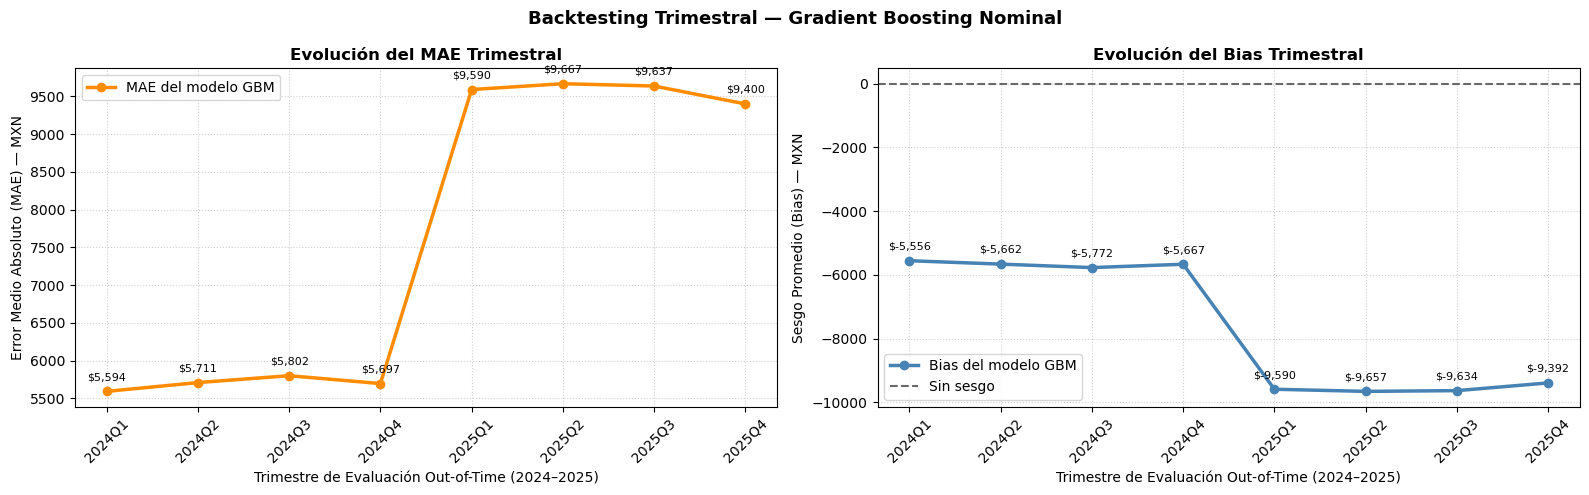

In [2]:

# BACKTESTING TRIMESTRAL INICIAL — GRADIENT BOOSTING


# Preprocesamiento encapsulado libre de Data Leakage
# tipo_vehiculo se transforma mediante One-Hot Encoding

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), ['tipo_vehiculo'])
    ],
    remainder='passthrough'
)


# MODELO NOMINAL CONGELADO
# Entrenamiento: 2021-2023


gbm_nominal = Pipeline([
    ('pre', preprocessor),
    ('model', GradientBoostingRegressor(random_state=2024))
])

gbm_nominal.fit(
    df_train[features],
    df_train[target]
)


# PREDICCIONES OUT-OF-TIME
# Periodo de prueba: 2024-2025


df_test['pred_nominal_gbm'] = gbm_nominal.predict(
    df_test[features]
)


# CÁLCULO DEL ERROR
# Convención: Predicho - Real


df_test['error_nom_gbm'] = (
    df_test['pred_nominal_gbm'] -
    df_test[target]
)


# CÁLCULO DEL ERROR PORCENTUAL ABSOLUTO


df_test['mape_nom_gbm'] = (
    np.abs(
        df_test['error_nom_gbm'] /
        df_test[target]
    ) * 100
)


# AGRUPACIÓN TRIMESTRAL


bt_gbm_inicial = df_test.groupby('trimestre').agg({
    'error_nom_gbm': [
        lambda x: np.abs(x).mean(),
        'mean'
    ],
    'mape_nom_gbm': 'mean'
}).reset_index()


# RENOMBRAR COLUMNAS


bt_gbm_inicial.columns = [
    'Año - Trimestre',
    'Error Medio Absoluto (MAE)',
    'Sesgo Promedio (Bias)',
    'Error Porcentual Absoluto Medio (MAPE)'
]

bt_gbm_inicial['Año - Trimestre'] = (
    bt_gbm_inicial['Año - Trimestre'].astype(str)
)


# RESULTADOS TRIMESTRALES


print("RENDIMIENTO TRIMESTRAL - GRADIENT BOOSTING")

display(
    bt_gbm_inicial.style.format({
        'Error Medio Absoluto (MAE)': '${:,.2f} MXN',
        'Sesgo Promedio (Bias)': '${:,.2f} MXN',
        'Error Porcentual Absoluto Medio (MAPE)': '{:.2f}%'
    })
)


# MÉTRICAS GLOBALES OUT-OF-TIME


mae_global_gbm = np.abs(
    df_test['error_nom_gbm']
).mean()

bias_global_gbm = (
    df_test['error_nom_gbm']
).mean()

mape_global_gbm = (
    df_test['mape_nom_gbm']
).mean()

print("\nRENDIMIENTO GLOBAL OUT-OF-TIME — GRADIENT BOOSTING")
print(f"MAE global OOT: ${mae_global_gbm:,.2f} MXN")
print(f"Bias global OOT: ${bias_global_gbm:,.2f} MXN")
print(f"MAPE global OOT: {mape_global_gbm:.2f}%")


# GRÁFICA — EVOLUCIÓN DEL MAE Y DEL  BIAS DEL MODELO NOMINAL GBM

fig, axes = plt.subplots(1,2,figsize=(16, 5))
fig.suptitle('Backtesting Trimestral — Gradient Boosting Nominal',fontsize=13,fontweight='bold')

# GRÁFICA 1 — MAE
axes[0].plot(
    bt_gbm_inicial['Año - Trimestre'],
    bt_gbm_inicial['Error Medio Absoluto (MAE)'],
    marker='o',
    linewidth=2.5,
    color='darkorange',
    label='MAE del modelo GBM'
)

axes[0].set_xlabel('Trimestre de Evaluación Out-of-Time (2024–2025)')
axes[0].set_ylabel('Error Medio Absoluto (MAE) — MXN')
axes[0].set_title('Evolución del MAE Trimestral',fontsize=12,fontweight='bold')
axes[0].tick_params(axis='x',rotation=45)
axes[0].grid(True,linestyle=':',alpha=0.6)
axes[0].legend()

# Etiquetas con el valor de MAE
for i, valor in enumerate(
    bt_gbm_inicial['Error Medio Absoluto (MAE)']
):
    axes[0].annotate(
        f'${valor:,.0f}',
        (bt_gbm_inicial['Año - Trimestre'].iloc[i],valor),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=8
    )

# GRÁFICA 2 — BIAS
axes[1].plot(
    bt_gbm_inicial['Año - Trimestre'],
    bt_gbm_inicial['Sesgo Promedio (Bias)'],
    marker='o',
    linewidth=2.5,
    color='steelblue',
    label='Bias del modelo GBM'
)

# Línea de referencia en cero
axes[1].axhline(
    0,
    color='dimgray',
    linestyle='--',
    linewidth=1.5,
    label='Sin sesgo'
)

axes[1].set_xlabel('Trimestre de Evaluación Out-of-Time (2024–2025)')
axes[1].set_ylabel('Sesgo Promedio (Bias) — MXN')
axes[1].set_title('Evolución del Bias Trimestral',fontsize=12,fontweight='bold')
axes[1].tick_params(axis='x',rotation=45)
axes[1].grid(True,linestyle=':',alpha=0.6)
axes[1].legend()

# Etiquetas con el valor de Bias
for i, valor in enumerate(
    bt_gbm_inicial['Sesgo Promedio (Bias)']
):
    axes[1].annotate(
        f'${valor:,.0f}',
        (
            bt_gbm_inicial['Año - Trimestre'].iloc[i],
            valor
        ),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=8
    )

plt.tight_layout()


### Comentario del Backtesting Inicial - Gradient Boosting

El modelo Gradient Boosting presenta un MAE global de **$7,632.33 MXN** y un Bias de **-$7,611.25 MXN** durante el periodo Out-of-Time (2024–2025). El Bias negativo en todos los trimestres indica que el modelo **subestima de manera sistemática el costo real de reparación**.

Además, se observa un deterioro en el desempeño al pasar de 2024 a 2025. Mientras que durante 2024 el Bias se mantiene alrededor de **-$5,600 MXN**, en 2025 aumenta su magnitud hasta aproximadamente **-$9,600 MXN**. Esto indica que el modelo entrenado con información de 2021–2023 pierde capacidad para representar adecuadamente el comportamiento observado en los años posteriores.

El MAPE de 20.02% complementa este diagnóstico al mostrar que, en términos relativos, el error porcentual promedio de las predicciones es considerable. En conjunto, el MAE, el Bias y el MAPE proporcionan evidencia de una pérdida de estabilidad del modelo al aplicarse sobre la muestra Out-of-Time.

Este resultado constituye la evidencia inicial de que existe un **cambio en el comportamiento de la cartera y/o del costo de los siniestros**, por lo que será necesario analizar las posibles fuentes de Drift antes de aplicar una estrategia de mitigación.


## 2.3 Diagnóstico del Drift

A partir del deterioro observado en el desempeño Out-of-Time, se analiza si la pérdida de estabilidad del modelo está relacionada con cambios en la composición de la cartera o con cambios en el nivel de costos de reparación.

### 2.3.1 Population Drift: Cambio en la Composición de la Cartera

Se compara la distribución de la edad de los conductores entre el periodo de entrenamiento y el periodo Out-of-Time, con el objetivo de identificar cambios en la composición de la cartera.

### 2.3.2 Concept Drift: Evolución del Costo de Reparación

Se analiza la evolución del costo de reparación entre el periodo de entrenamiento y el periodo Out-of-Time. Asimismo, se incorpora el índice de costo de refacciones utilizado para representar la inflación de los componentes necesarios para la reparación de los vehículos.

EVOLUCIÓN DEL ÍNDICE DE COSTO DE REFACCIONES


,Año,Índice de costo de refacciones
0,2021,1.00
1,2022,1.07
2,2023,1.15
3,2024,1.28
4,2025,1.42


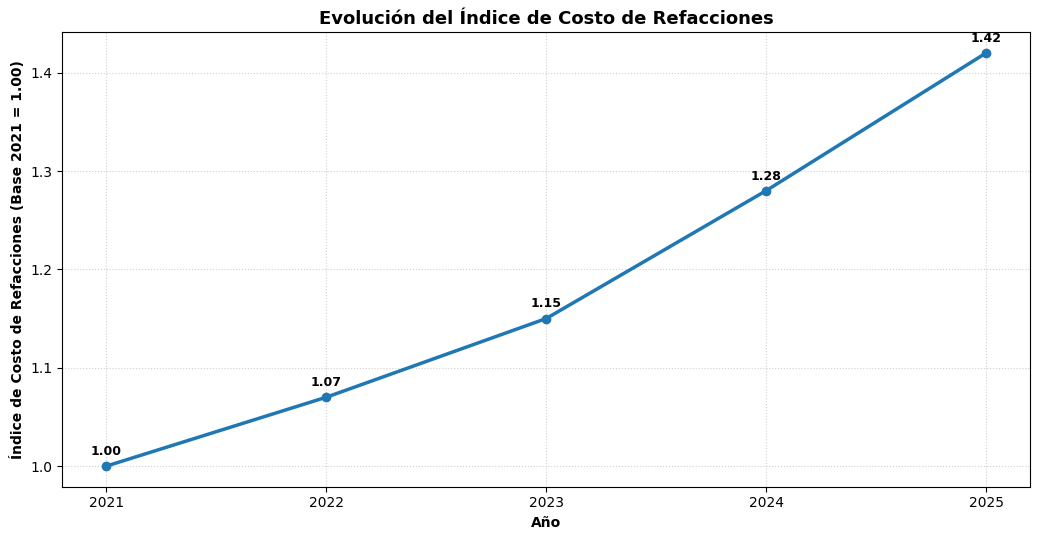

DIAGNÓSTICO DE DRIFT — CAMBIO EN LA CARTERA Y EN EL COSTO


,Indicador Demográfico (Mix de Cartera),Indicador Económico (Costo de Reparación)
Monitoreo del cambio entre periodos,Edad media Train: 43.6 años | Test: 26.0 años | Cambio: -40.3%,"Costo medio Train: $23,635.64 | Test: $36,903.25 | Cambio: +56.1%"


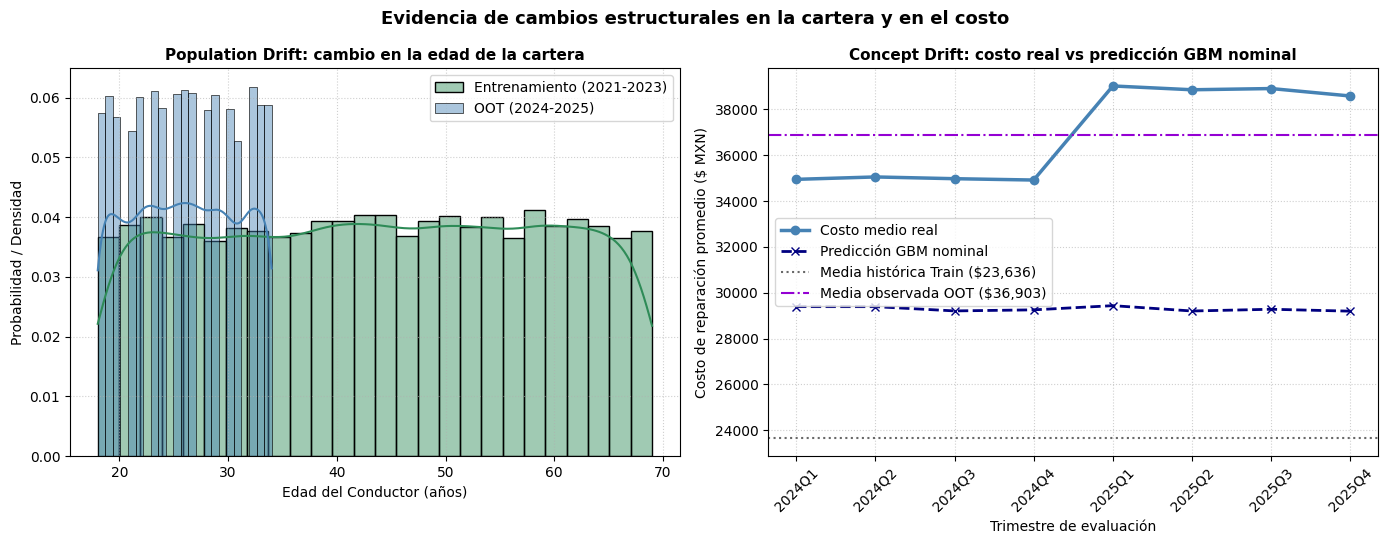

In [174]:

# DIAGNÓSTICO DE DRIFT — GRADIENT BOOSTING
# Population Drift + Concept Drift



# CÁLCULO ANALÍTICO DEL DRIFT


# ¿Cambio en la composición de la cartera: edad promedio?

edad_train_media = df_train['edad_conductor'].mean()
edad_test_media = df_test['edad_conductor'].mean()

cambio_edad_pct = (
    (edad_test_media - edad_train_media)
    / edad_train_media
) * 100


# ¿Cambio en el nivel promedio del costo de reparación?

costo_train_medio = df_train[target].mean()
costo_test_medio = df_test[target].mean()

cambio_costo_pct = (
    (costo_test_medio - costo_train_medio)
    / costo_train_medio
) * 100




# EVOLUCIÓN DEL ÍNDICE DE COSTO DE REFACCIONES


indice_refacciones = pd.DataFrame({
    'Año': [2021, 2022, 2023, 2024, 2025],
    'Índice de costo de refacciones': [1.00, 1.07, 1.15, 1.28, 1.42]
})

print("EVOLUCIÓN DEL ÍNDICE DE COSTO DE REFACCIONES")

display(
    indice_refacciones.style.format({
        'Índice de costo de refacciones': '{:.2f}'
    })
)


# GRÁFICA 


plt.figure(figsize=(10.5, 5.5))

plt.plot(
    indice_refacciones['Año'],
    indice_refacciones['Índice de costo de refacciones'],
    marker='o',
    linewidth=2.5
)

plt.title(
    'Evolución del Índice de Costo de Refacciones',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel(
    'Año',
    fontweight='bold'
)

plt.ylabel(
    'Índice de Costo de Refacciones (Base 2021 = 1.00)',
    fontweight='bold'
)

plt.xticks(indice_refacciones['Año'])

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

# Etiquetas de los valores
for x, y in zip(
    indice_refacciones['Año'],
    indice_refacciones['Índice de costo de refacciones']
):
    plt.annotate(
        f'{y:.2f}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


# TABLA DEL DIAGNÓSTICO


df_resumen_drift = pd.DataFrame({
    'Indicador Demográfico (Mix de Cartera)': [
        f"Edad media Train: {edad_train_media:.1f} años | "
        f"Test: {edad_test_media:.1f} años | "
        f"Cambio: {cambio_edad_pct:.1f}%"
    ],

    'Indicador Económico (Costo de Reparación)': [
        f"Costo medio Train: ${costo_train_medio:,.2f} | "
        f"Test: ${costo_test_medio:,.2f} | "
        f"Cambio: {cambio_costo_pct:+.1f}%"
    ]

}, index=['Monitoreo del cambio entre periodos'])


print("DIAGNÓSTICO DE DRIFT — CAMBIO EN LA CARTERA Y EN EL COSTO")

#display(df_resumen_drift)
display(
    df_resumen_drift.style.format({
        'Indicador Demográfico (Mix de Cartera)': '{}',
        'Indicador Económico (Costo de Reparación)': '{}'
    })
)

# PANEL VISUAL DEL DIAGNÓSTICO


fig, axs = plt.subplots(1, 2, figsize=(14, 5.5))

fig.suptitle(
    'Evidencia de cambios estructurales en la cartera y en el costo',
    fontsize=13,
    fontweight='bold'
)



# PANEL IZQUIERDO — POPULATION DRIFT


sns.histplot(
    df_train['edad_conductor'],
    kde=True,
    color='seagreen',
    label='Entrenamiento (2021-2023)',
    stat='probability',
    ax=axs[0],
    alpha=0.45
)

sns.histplot(
    df_test['edad_conductor'],
    kde=True,
    color='steelblue',
    label='OOT (2024-2025)',
    stat='probability',
    ax=axs[0],
    alpha=0.45
)

axs[0].set_title(
    'Population Drift: cambio en la edad de la cartera',
    fontsize=11,
    fontweight='bold'
)

axs[0].set_xlabel('Edad del Conductor (años)')
axs[0].set_ylabel('Probabilidad / Densidad')

axs[0].grid(
    True,
    linestyle=':',
    alpha=0.6
)

axs[0].legend()



# PANEL DERECHO — CONCEPT DRIFT


costo_trim_gbm = df_test.groupby('trimestre').agg(
    costo_real=(target, 'mean'),
    pred_gbm=('pred_nominal_gbm', 'mean')
).reset_index()

costo_trim_gbm['trimestre_str'] = (
    costo_trim_gbm['trimestre'].astype(str)
)


# Costo real observado

axs[1].plot(
    costo_trim_gbm['trimestre_str'],
    costo_trim_gbm['costo_real'],
    marker='o',
    color='steelblue',
    linewidth=2.5,
    label='Costo medio real'
)


# Predicción del modelo GBM nominal congelado

axs[1].plot(
    costo_trim_gbm['trimestre_str'],
    costo_trim_gbm['pred_gbm'],
    marker='x',
    color='navy',
    linestyle='--',
    linewidth=2,
    label='Predicción GBM nominal'
)


# Media histórica del periodo de entrenamiento

axs[1].axhline(
    costo_train_medio,
    color='dimgray',
    linestyle=':',
    linewidth=1.5,
    label=f'Media histórica Train (${costo_train_medio:,.0f})'
)


# Media observada durante el periodo OOT

axs[1].axhline(
    costo_test_medio,
    color='darkviolet',
    linestyle='-.',
    linewidth=1.5,
    label=f'Media observada OOT (${costo_test_medio:,.0f})'
)


axs[1].set_title(
    'Concept Drift: costo real vs predicción GBM nominal',
    fontsize=11,
    fontweight='bold'
)

axs[1].set_xlabel('Trimestre de evaluación')
axs[1].set_ylabel('Costo de reparación promedio ($ MXN)')

axs[1].grid(
    True,
    linestyle=':',
    alpha=0.6
)

axs[1].legend()
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Diagnóstico de cambios entre entrenamiento y periodo OOT

Al comparar los periodos de entrenamiento y evaluación se observa un cambio importante en la composición de la cartera. La edad media de los conductores disminuye de **43.6 años en Train a 26.0 años en Test**, lo que representa un desplazamiento de **40.3%** y evidencia un rejuvenecimiento de la cartera a partir de 2024.

Por otra parte, el costo medio de reparación aumenta de **$23,635.64 a $36,903.25 MXN**, equivalente a un incremento de **56.1%**. Este cambio en el nivel del costo ayuda a explicar la subestimación observada en el modelo nominal durante el periodo Out-of-Time.

Adicionalmente, el índice de costo de refacciones presenta una tendencia creciente, pasando de **1.15 en 2023 a 1.28 en 2024 y 1.42 en 2025**. Esto indica un cambio sistemático en el nivel monetario del costo de reparación que no estaba presente con la misma magnitud durante el periodo utilizado para entrenar el modelo.

En conjunto, los resultados muestran un cambio relevante tanto en la composición de la cartera como en el nivel del costo observado. Por ello, resulta necesario evaluar estrategias que permitan adaptar el modelo a estos cambios sin utilizar información futura de manera indebida.


## 2.4 Mitigación del Drift

A partir del diagnóstico realizado, se implementan dos estrategias de corrección para evaluar su capacidad de recuperar la estabilidad predictiva del modelo:

1. **Estrategia A:** Deflactación del costo de reparación mediante el índice de costo de refacciones.
2. **Estrategia B:** Entrenamiento adaptativo mediante una ventana móvil de 24 meses.

### 2.4.1 Estrategia A: Feature Engineering Actuarial — Deflactación

La severidad observada durante el entrenamiento se transforma a pesos constantes utilizando el índice de costo de refacciones. El modelo se entrena sobre el costo deflactado y posteriormente las predicciones se re-indexan al nivel de costos correspondiente al periodo de prueba.

In [175]:

# FUNCIÓN PARA CALCULAR MAPE


def calcular_mape(y_real, y_pred):
    """
    Calcula el Mean Absolute Percentage Error (MAPE).
    Se excluyen observaciones cuyo valor real sea cero.
    """

    mascara = y_real != 0

    return (
        np.abs(
            (y_real[mascara] - y_pred[mascara])
            / y_real[mascara]
        ).mean()
        * 100
    )

In [176]:

# MITIGACIÓN DEL DRIFT — GRADIENT BOOSTING
# ESTRATEGIA A: DEFLACTACIÓN




# ESTRATEGIA A — FEATURE ENGINEERING ACTUARIAL
# DEFLACTACIÓN / INDEXACIÓN DEL COSTO


# Deflactar el costo de reparación del periodo de entrenamiento
# a pesos constantes de 2021

df_train['costo_deflactado'] = (
    df_train[target]
    / df_train['indice_costo_refaccion']
)


# Modelo GBM entrenado con el costo de reparación deflactado

gbm_actuarial = Pipeline([
    ('pre', preprocessor),
    ('model', GradientBoostingRegressor(random_state=2024))
])

gbm_actuarial.fit(
    df_train[features],
    df_train['costo_deflactado']
)


# Predicción en pesos constantes y re-indexación
# al nivel de costos observado en el periodo OOT

df_test['pred_def_gbm'] = (
    gbm_actuarial.predict(df_test[features])
    * df_test['indice_costo_refaccion']
)


# Convención del error: Predicho - Real

df_test['error_def_gbm'] = (
    df_test['pred_def_gbm']
    - df_test[target]
)

### 2.4.2 Estrategia B: Entrenamiento Adaptativo — Rolling Window de 24 Meses

In [177]:

# MITIGACIÓN DEL DRIFT — GRADIENT BOOSTING
# ESTRATEGIA B — ENTRENAMIENTO ADAPTATIVO
# VENTANA MÓVIL DE 24 MESES


# Se crea una columna vacía para almacenar las predicciones
# de los modelos correspondientes a cada ventana.

df_test['pred_estat_B'] = np.nan



# MODELO PARA 2024
# Ventana de entrenamiento: enero 2022 - diciembre 2023


mask_train_2024 = (
    (df_tarea['fecha_siniestro'] >= '2022-01-01') &
    (df_tarea['fecha_siniestro'] < '2024-01-01')
)

mask_test_2024 = (
    df_test['fecha_siniestro'].dt.year == 2024
)


gbm_2024 = Pipeline([
    ('pre', preprocessor),
    ('model', GradientBoostingRegressor(random_state=2024))
])

gbm_2024.fit(
    df_tarea.loc[mask_train_2024, features],
    df_tarea.loc[mask_train_2024, target]
)


df_test.loc[mask_test_2024, 'pred_estat_B'] = (
    gbm_2024.predict(
        df_test.loc[mask_test_2024, features]
    )
)



# MODELO PARA 2025
# Ventana de entrenamiento: enero 2023 - diciembre 2024


mask_train_2025 = (
    (df_tarea['fecha_siniestro'] >= '2023-01-01') &
    (df_tarea['fecha_siniestro'] < '2025-01-01')
)

mask_test_2025 = (
    df_test['fecha_siniestro'].dt.year == 2025
)


gbm_2025 = Pipeline([
    ('pre', preprocessor),
    ('model', GradientBoostingRegressor(random_state=2024))
])

gbm_2025.fit(
    df_tarea.loc[mask_train_2025, features],
    df_tarea.loc[mask_train_2025, target]
)


df_test.loc[mask_test_2025, 'pred_estat_B'] = (
    gbm_2025.predict(
        df_test.loc[mask_test_2025, features]
    )
)



# ERROR DE LA ESTRATEGIA B
# Convención: Predicho - Real


df_test['error_wf_gbm'] = (
    df_test['pred_estat_B']
    - df_test[target]
)


### 2.4.3 Resultados y Comparación de Estrategias 

Para comparar las estrategias bajo una misma medida de desempeño, se integran las predicciones correspondientes a todo el periodo Out-of-Time (2024–2025) y se calculan las métricas sobre el conjunto completo de observaciones evaluadas.

En el caso de la Estrategia B, los modelos se actualizan mediante dos ventanas móviles de 24 meses: para 2024 se utiliza información de 2022–2023, mientras que para 2025 se utiliza información de 2023–2024. Por ello, los resultados globales reportados para esta estrategia no corresponden a un promedio simple de las métricas obtenidas en cada ventana, sino al cálculo directo de MAE, Bias y MAPE sobre todas las observaciones del periodo Out-of-Time.

Esta medida permite realizar una comparación consistente entre el Modelo Nominal, la Estrategia A y la Estrategia B, ya que las tres configuraciones son evaluadas sobre el mismo periodo Out-of-Time.

In [178]:

# RESULTADOS DE LA ESTRATEGIA B POR VENTANA



# VENTANA 2024
# Entrenamiento: 2022–2023
# Evaluación: 2024


mae_2024 = np.abs(
    df_test.loc[mask_test_2024, 'error_wf_gbm']
).mean()

bias_2024 = (
    df_test.loc[mask_test_2024, 'error_wf_gbm']
).mean()

mape_2024 = calcular_mape(
    df_test.loc[mask_test_2024, target],
    df_test.loc[mask_test_2024, 'pred_estat_B']
)



# VENTANA 2025
# Entrenamiento: 2023–2024
# Evaluación: 2025


mae_2025 = np.abs(
    df_test.loc[mask_test_2025, 'error_wf_gbm']
).mean()

bias_2025 = (
    df_test.loc[mask_test_2025, 'error_wf_gbm']
).mean()

mape_2025 = calcular_mape(
    df_test.loc[mask_test_2025, target],
    df_test.loc[mask_test_2025, 'pred_estat_B']
)



# TABLA DETALLADA — ESTRATEGIA B


df_rolling_gbm = pd.DataFrame({

    'Periodo de evaluación': [
        '2024',
        '2025'
    ],

    'Ventana de entrenamiento': [
        '2022–2023',
        '2023–2024'
    ],

    'Error Medio Absoluto (MAE)': [
        mae_2024,
        mae_2025
    ],

    'Sesgo Promedio (Bias)': [
        bias_2024,
        bias_2025
    ],

    'MAPE (%)': [
        mape_2024,
        mape_2025
    ]

})


print(
    "ESTRATEGIA B — RESULTADOS POR VENTANA DE 24 MESES"
)

display(
    df_rolling_gbm.style.format({

        'Error Medio Absoluto (MAE)':
            '${:,.2f} MXN',

        'Sesgo Promedio (Bias)':
            '${:,.2f} MXN',

        'MAPE (%)':
            '{:.2f}%'

    })
)



# MÉTRICAS GLOBALES DE COMPARACIÓN




# MODELO NOMINAL


nom_mae = np.abs(
    df_test['error_nom_gbm']
).mean()

nom_bias = (
    df_test['error_nom_gbm']
).mean()

nom_mape = calcular_mape(
    df_test[target],
    df_test['pred_nominal_gbm']
)



# ESTRATEGIA A — DEFLACTACIÓN


a_mae = np.abs(
    df_test['error_def_gbm']
).mean()

a_bias = (
    df_test['error_def_gbm']
).mean()

a_mape = calcular_mape(
    df_test[target],
    df_test['pred_def_gbm']
)



# ESTRATEGIA B — VENTANA MÓVIL DE 24 MESES


# Métricas globales combinando las observaciones de 2024 y 2025.
# Estas métricas se utilizan únicamente para la comparación final
# entre configuraciones.

b_mae = np.abs(
    df_test['error_wf_gbm']
).mean()

b_bias = (
    df_test['error_wf_gbm']
).mean()

b_mape = calcular_mape(
    df_test[target],
    df_test['pred_estat_B']
)



# TABLA COMPARATIVA GLOBAL


df_mitigacion_final = pd.DataFrame({

    'Configuración del Modelo': [
        'Modelo Nominal Fijo',
        'Estrategia A: Deflactación',
        'Estrategia B: Ventana móvil 24 meses'
    ],

    'Error Medio Absoluto (MAE)': [
        nom_mae,
        a_mae,
        b_mae
    ],

    'Sesgo Promedio (Bias)': [
        nom_bias,
        a_bias,
        b_bias
    ],

    'MAPE (%)': [
        nom_mape,
        a_mape,
        b_mape
    ]

})



# REDUCCIÓN DEL MAE RESPECTO AL MODELO NOMINAL


df_mitigacion_final['Reducción MAE (%)'] = (
    (
        nom_mae
        - df_mitigacion_final['Error Medio Absoluto (MAE)']
    )
    / nom_mae
) * 100



# RESULTADOS GLOBALES


print(
    "RENDIMIENTO COMPARATIVO Y MITIGACIÓN DEL DRIFT — "
    "GRADIENT BOOSTING"
)


display(
    df_mitigacion_final.style.format({

        'Error Medio Absoluto (MAE)':
            '${:,.2f} MXN',

        'Sesgo Promedio (Bias)':
            '${:,.2f} MXN',

        'MAPE (%)':
            '{:.2f}%',

        'Reducción MAE (%)':
            '{:+.2f}%'

    })
)

ESTRATEGIA B — RESULTADOS POR VENTANA DE 24 MESES


,Periodo de evaluación,Ventana de entrenamiento,Error Medio Absoluto (MAE),Sesgo Promedio (Bias),MAPE (%)
0,2024,2022–2023,"$4,748.63 MXN","$-4,654.80 MXN",13.15%
1,2025,2023–2024,"$4,894.65 MXN","$-4,762.49 MXN",12.22%


RENDIMIENTO COMPARATIVO Y MITIGACIÓN DEL DRIFT — GRADIENT BOOSTING


,Configuración del Modelo,Error Medio Absoluto (MAE),Sesgo Promedio (Bias),MAPE (%),Reducción MAE (%)
0,Modelo Nominal Fijo,"$7,632.33 MXN","$-7,611.25 MXN",20.02%,+0.00%
1,Estrategia A: Deflactación,"$2,164.03 MXN",$-44.67 MXN,6.04%,+71.65%
2,Estrategia B: Ventana móvil 24 meses,"$4,821.45 MXN","$-4,708.50 MXN",12.69%,+36.83%


### Resultados de la mitigación del drift

Los resultados muestran que ambas estrategias permiten mejorar el desempeño del modelo **Gradient Boosting** respecto al modelo nominal fijo. Sin embargo, la magnitud de la mejora es diferente entre ambas alternativas.

La **Estrategia A, basada en la deflactación de la severidad**, presenta el mejor desempeño. El MAE disminuye de **$7,632.33 a $2,164.03 MXN**, lo que representa una reducción de **71.65%**. Asimismo, el MAPE disminuye de **20.02% a 6.04%**, evidenciando una reducción importante del error relativo. El Bias pasa de **-$7,611.25 a -$44.67 MXN**, por lo que la subestimación sistemática observada en el modelo nominal prácticamente desaparece.

Por su parte, la **Estrategia B, mediante una ventana móvil de 24 meses**, también mejora el desempeño, aunque sus resultados deben analizarse de manera independiente para cada periodo de evaluación. Para **2024**, utilizando información de 2022–2023 para el entrenamiento, se obtiene un MAE de **$4,748.63 MXN**, un Bias de **-$4,654.80 MXN** y un MAPE de **13.15%**. Para **2025**, utilizando información de 2023–2024, el MAE es de **$4,894.65 MXN**, el Bias de **-$4,762.49 MXN** y el MAPE de **12.22%**.

Estos resultados muestran que la ventana móvil permite reducir el error respecto al modelo nominal y mantener un desempeño relativamente estable entre ambos años. Sin embargo, la subestimación continúa siendo relevante, ya que el Bias permanece alrededor de **-$4,700 MXN** por siniestro.

Para efectos de la comparación global de las estrategias, la ventana móvil de 24 meses presenta un **MAE agregado de $4,821.45 MXN**, un **Bias de -$4,708.50 MXN** y un **MAPE de 12.69%**, frente a los valores de $7,632.33 MXN, -$7,611.25 MXN y 20.02%, respectivamente, del modelo nominal fijo. Esto representa una **reducción del MAE de 36.83%**.

Por lo tanto, para este conjunto de datos, la **Estrategia A resulta más efectiva para mitigar el deterioro del modelo**. La reducción simultánea del MAE, MAPE y Bias indica que la deflactación permite recuperar una mayor estabilidad en las estimaciones. En comparación, la ventana móvil aprovecha información más reciente de la cartera, pero no logra corregir completamente el efecto asociado al incremento del nivel de costos de reparación.

En consecuencia, los resultados respaldan la selección de la **Estrategia A como mecanismo principal de mitigación**, al ser la alternativa que logra reducir de manera más significativa el error absoluto, el error relativo y la subestimación sistemática.

# 3. Modelo 2: Regresión Lineal

Con el objetivo de evaluar si las conclusiones obtenidas dependen del algoritmo utilizado, se repite el ejercicio empleando Regresión Lineal como segundo modelo supervisado.

## 3.1 Backtesting Inicial Out-of-Time

La Regresión Lineal se entrena utilizando el mismo periodo histórico, 2021–2023, y se evalúa sobre la misma muestra Out-of-Time, correspondiente a 2024–2025.

Se mantienen las mismas variables explicativas y la misma convención de cálculo del error utilizada para Gradient Boosting.

RENDIMIENTO TRIMESTRAL — REGRESIÓN LINEAL


,Año - Trimestre,Error Medio Absoluto (MAE),Sesgo Promedio (Bias),MAPE (%)
0,2024Q1,"$5,587.45 MXN","$-5,548.16 MXN",15.54%
1,2024Q2,"$5,712.03 MXN","$-5,665.18 MXN",15.80%
2,2024Q3,"$5,810.28 MXN","$-5,780.18 MXN",16.17%
3,2024Q4,"$5,714.69 MXN","$-5,681.21 MXN",15.92%
4,2025Q1,"$9,595.44 MXN","$-9,595.23 MXN",24.15%
5,2025Q2,"$9,663.39 MXN","$-9,652.77 MXN",24.47%
6,2025Q3,"$9,650.95 MXN","$-9,648.13 MXN",24.37%
7,2025Q4,"$9,392.34 MXN","$-9,384.66 MXN",23.87%


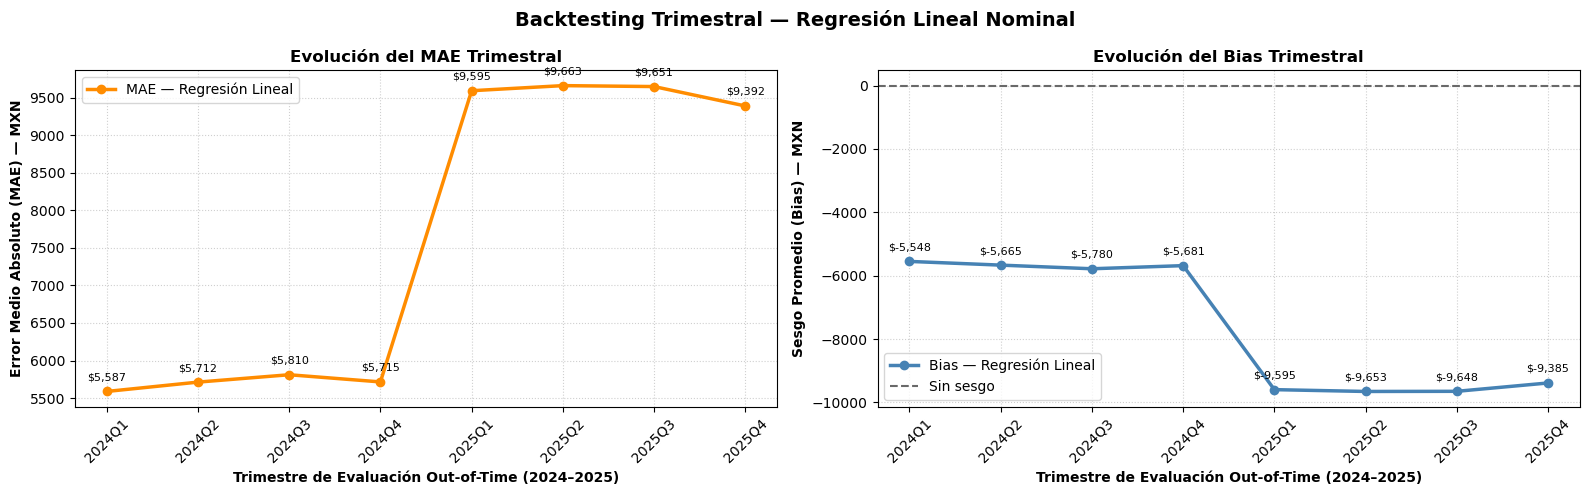


RENDIMIENTO GLOBAL OUT-OF-TIME — REGRESIÓN LINEAL
MAE global OOT: $7,635.89 MXN
Bias global OOT: $-7,614.47 MXN
MAPE global OOT: 20.03%


In [3]:

# BACKTESTING INICIAL — REGRESIÓN LINEAL



# MODELO NOMINAL CONGELADO
# Entrenamiento: 2021-2023


pipe_nom_lr_inicial = Pipeline([
    ('pre', preprocessor),
    ('model', LinearRegression())
])

pipe_nom_lr_inicial.fit(
    df_train[features],
    df_train[target]
)



# PREDICCIONES OUT-OF-TIME
# Periodo de prueba: 2024-2025


df_test['pred_nominal_lr'] = (
    pipe_nom_lr_inicial.predict(df_test[features])
)

# CÁLCULO DEL ERROR
# Convención: Predicho - Real
df_test['error_nom_lr'] = (
    df_test['pred_nominal_lr']
    - df_test[target]
)



# MÉTRICAS POR TRIMESTRE


bt_lr_inicial = df_test.groupby('trimestre').agg(
    MAE_Nominal_LR=(
        'error_nom_lr',
        lambda x: np.abs(x).mean()
    ),
    Bias_Nominal_LR=(
        'error_nom_lr',
        'mean'
    )
).reset_index()



# MAPE POR TRIMESTRE


mape_lr = (
    df_test.groupby('trimestre', group_keys=False)
    .apply(
        lambda g: np.mean(
            np.abs(
                (g[target] - g['pred_nominal_lr'])
                / g[target]
            )
        ) * 100,
        include_groups=False
    )
    .reset_index(name='MAPE_Nominal_LR')
)



# UNIR MAPE A LA TABLA DE MÉTRICAS


bt_lr_inicial = bt_lr_inicial.merge(
    mape_lr,
    on='trimestre'
)



# TABLA


bt_lr_inicial.columns = [
    'Año - Trimestre',
    'Error Medio Absoluto (MAE)',
    'Sesgo Promedio (Bias)',
    'MAPE (%)'
]

bt_lr_inicial['Año - Trimestre'] = (
    bt_lr_inicial['Año - Trimestre'].astype(str)
)



# RESULTADOS POR TRIMESTRE


print("RENDIMIENTO TRIMESTRAL — REGRESIÓN LINEAL")

display(
    bt_lr_inicial.style.format({
        'Error Medio Absoluto (MAE)': '${:,.2f} MXN',
        'Sesgo Promedio (Bias)': '${:,.2f} MXN',
        'MAPE (%)': '{:.2f}%'
    })
)


# GRÁFICA

fig, axes = plt.subplots(1,2,figsize=(16, 5))

fig.suptitle(
    'Backtesting Trimestral — Regresión Lineal Nominal',
    fontsize=14,
    fontweight='bold'
)

axes[0].plot(
    bt_lr_inicial['Año - Trimestre'],
    bt_lr_inicial['Error Medio Absoluto (MAE)'],
    marker='o',
    linewidth=2.5,
    color='darkorange',
    label='MAE — Regresión Lineal'
)

axes[0].set_title('Evolución del MAE Trimestral',fontsize=12,fontweight='bold')
axes[0].set_xlabel('Trimestre de Evaluación Out-of-Time (2024–2025)',fontweight='bold')
axes[0].set_ylabel('Error Medio Absoluto (MAE) — MXN',fontweight='bold')
axes[0].tick_params(axis='x',rotation=45)
axes[0].grid(True,linestyle=':',alpha=0.6)
axes[0].legend()


# Etiquetas de MAE
for i, valor in enumerate(
    bt_lr_inicial['Error Medio Absoluto (MAE)']
):
    axes[0].annotate(
        f'${valor:,.0f}',
        (
            bt_lr_inicial['Año - Trimestre'].iloc[i],
            valor
        ),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=8
    )

# Grafica 3

axes[1].plot(
    bt_lr_inicial['Año - Trimestre'],
    bt_lr_inicial['Sesgo Promedio (Bias)'],
    marker='o',
    linewidth=2.5,
    color='steelblue',
    label='Bias — Regresión Lineal'
)

# Línea de referencia: Bias = 0
axes[1].axhline(
    0,
    color='dimgray',
    linestyle='--',
    linewidth=1.5,
    label='Sin sesgo'
)

axes[1].set_title('Evolución del Bias Trimestral',fontsize=12,fontweight='bold')
axes[1].set_xlabel('Trimestre de Evaluación Out-of-Time (2024–2025)',fontweight='bold')
axes[1].set_ylabel('Sesgo Promedio (Bias) — MXN',fontweight='bold')
axes[1].tick_params(axis='x',rotation=45)
axes[1].grid(True,linestyle=':',alpha=0.6)
axes[1].legend()

for i, valor in enumerate(
    bt_lr_inicial['Sesgo Promedio (Bias)']
):
    axes[1].annotate(
        f'${valor:,.0f}',
        (
            bt_lr_inicial['Año - Trimestre'].iloc[i],
            valor
        ),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=8
    )


plt.tight_layout()
plt.show()


# MÉTRICAS GLOBALES OUT-OF-TIME


mae_global_lr = np.abs(
    df_test['error_nom_lr']
).mean()

bias_global_lr = (
    df_test['error_nom_lr']
).mean()

mape_global_lr = np.mean(
    np.abs(
        (df_test[target] - df_test['pred_nominal_lr'])
        / df_test[target]
    )
) * 100


print("\nRENDIMIENTO GLOBAL OUT-OF-TIME — REGRESIÓN LINEAL")
print(f"MAE global OOT: ${mae_global_lr:,.2f} MXN")
print(f"Bias global OOT: ${bias_global_lr:,.2f} MXN")
print(f"MAPE global OOT: {mape_global_lr:.2f}%")

### Comentario del Backtesting Inicial - Regresión Lineal

El modelo de **Regresión Lineal** presenta un comportamiento similar al observado previamente con Gradient Boosting. Durante 2024, el MAE se mantiene aproximadamente entre **$5,587 y $5,810 MXN**, mientras que el Bias permanece negativo, entre **-$5,548 y -$5,780 MXN**, lo que indica una subestimación sistemática del costo de reparación. El MAPE se mantiene alrededor de **15.5%–16.2%** durante este año.

En 2025 se observa un deterioro más pronunciado. El MAE aumenta a valores cercanos a **$9,400–$9,700 MXN** y el Bias se mantiene alrededor de **-$9,400 a -$9,650 MXN**. De manera consistente, el MAPE aumenta hasta valores cercanos al **24%**, mostrando un incremento importante del error relativo respecto al año anterior.

El comportamiento observado en la Regresión Lineal es consistente con el obtenido mediante **Gradient Boosting**: ambos modelos, al mantenerse congelados con información de 2021–2023, presentan una subestimación importante durante 2024–2025 y un deterioro más evidente en 2025. Esto sugiere que el problema no depende únicamente de la elección del algoritmo, sino que está relacionado con los cambios estructurales identificados previamente en la cartera y en el nivel de costos de reparación.



## 3.2 Diagnóstico del Drift

El Population Drift y el Concept Drift identificados anteriormente corresponden a cambios en la cartera y en el nivel de costos de reparación, por lo que no dependen del algoritmo utilizado.

Por esta razón, las condiciones de drift identificadas para Gradient Boosting se mantienen para la Regresión Lineal. Para comprobar su efecto sobre este segundo modelo, se analiza la evolución de sus predicciones frente al costo real durante el periodo Out-of-Time.

### 3.2.1 Costo Real vs. Predicción Nominal de Regresión Lineal

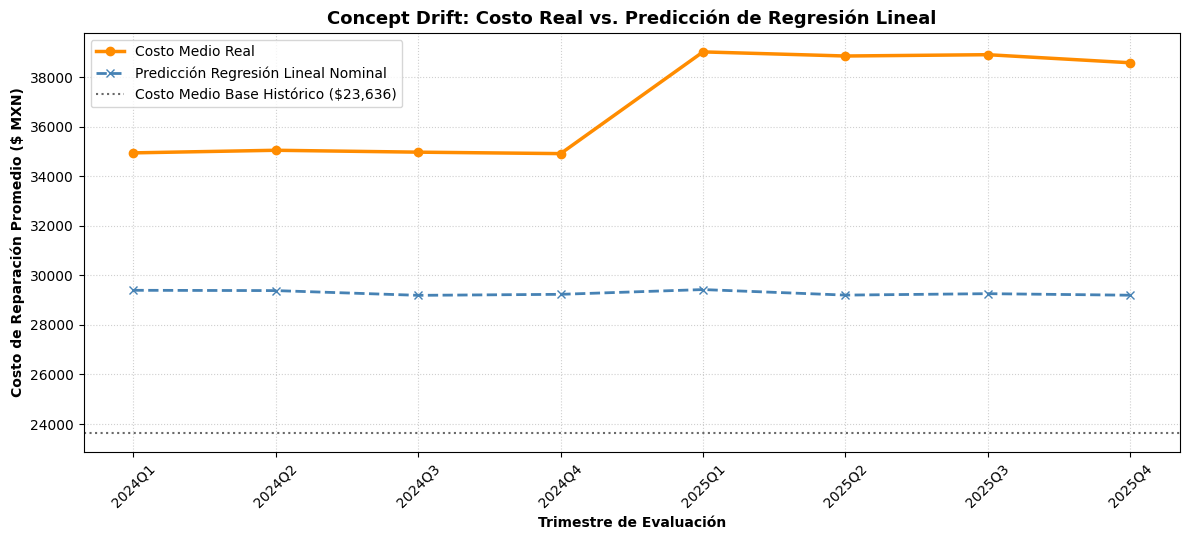

In [180]:

# GRÁFICA — REGRESIÓN LINEAL NOMINAL VS. COSTO REAL


costo_trim_lr = df_test.groupby('trimestre').agg(
    costo_real=(target, 'mean'),
    pred_lr=('pred_nominal_lr', 'mean')
).reset_index()

costo_trim_lr['trimestre_str'] = (
    costo_trim_lr['trimestre'].astype(str)
)

plt.figure(figsize=(12, 5.5))

# Costo real observado
plt.plot(
    costo_trim_lr['trimestre_str'],
    costo_trim_lr['costo_real'],
    marker='o',
    linewidth=2.5,
    color='darkorange',
    label='Costo Medio Real'
)

# Predicción del modelo congelado
plt.plot(
    costo_trim_lr['trimestre_str'],
    costo_trim_lr['pred_lr'],
    marker='x',
    linestyle='--',
    linewidth=2,
    color='steelblue',
    label='Predicción Regresión Lineal Nominal'
)

# Costo medio histórico del periodo de entrenamiento
plt.axhline(
    costo_train_medio,
    color='dimgray',
    linestyle=':',
    linewidth=1.5,
    label=f'Costo Medio Base Histórico (${costo_train_medio:,.0f})'
)

plt.title(
    'Concept Drift: Costo Real vs. Predicción de Regresión Lineal',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel(
    'Trimestre de Evaluación',
    fontweight='bold'
)

plt.ylabel(
    'Costo de Reparación Promedio ($ MXN)',
    fontweight='bold'
)

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Comentario

La gráfica muestra que la Regresión Lineal nominal presenta una subestimación sistemática del costo de reparación durante el periodo Out-of-Time. La diferencia entre el costo real y la predicción se mantiene durante 2024 y se hace más evidente en 2025, consistente con el sesgo negativo observado en la evaluación trimestral.

## 3.3 Mitigación del Drift

### 3.3.1 Estrategia A: Feature Engineering Actuarial — Deflactación

In [181]:

# REGRESIÓN LINEAL — ESTRATEGIAS DE MITIGACIÓN DEL DRIFT




# ESTRATEGIA A — FEATURE ENGINEERING ACTUARIAL
# DEFLACTACIÓN / INDEXACIÓN DEL COSTO


# Deflactar el costo de reparación del periodo de entrenamiento
# a pesos constantes de 2021

df_train['costo_deflactado_lr'] = (
    df_train[target]
    / df_train['indice_costo_refaccion']
)


# Modelo de Regresión Lineal entrenado con el costo deflactado

lr_actuarial = Pipeline([
    ('pre', preprocessor),
    ('model', LinearRegression())
])

lr_actuarial.fit(
    df_train[features],
    df_train['costo_deflactado_lr']
)


# Predicción en pesos constantes y re-indexación
# al nivel de costos observado en el periodo OOT

df_test['pred_def_lr'] = (
    lr_actuarial.predict(df_test[features])
    * df_test['indice_costo_refaccion']
)


# Convención del error: Predicho - Real

df_test['error_def_lr'] = (
    df_test['pred_def_lr']
    - df_test[target]
)

### 3.3.2 Estrategia B: Entrenamiento Adaptativo — Rolling Window de 24 Meses

In [182]:

# ESTRATEGIA B — ENTRENAMIENTO ADAPTATIVO
# ROLLING WINDOW DE 24 MESES


df_test['pred_rolling_lr'] = np.nan



# MODELO PARA 2024
# Ventana de entrenamiento: enero 2022 - diciembre 2023


mask_train_lr_2024 = (
    (df_tarea['fecha_siniestro'] >= '2022-01-01') &
    (df_tarea['fecha_siniestro'] < '2024-01-01')
)

mask_test_lr_2024 = (
    df_test['fecha_siniestro'].dt.year == 2024
)


lr_2024 = Pipeline([
    ('pre', preprocessor),
    ('model', LinearRegression())
])

lr_2024.fit(
    df_tarea.loc[mask_train_lr_2024, features],
    df_tarea.loc[mask_train_lr_2024, target]
)


df_test.loc[mask_test_lr_2024, 'pred_rolling_lr'] = (
    lr_2024.predict(
        df_test.loc[mask_test_lr_2024, features]
    )
)



# MODELO PARA 2025
# Ventana de entrenamiento: enero 2023 - diciembre 2024


mask_train_lr_2025 = (
    (df_tarea['fecha_siniestro'] >= '2023-01-01') &
    (df_tarea['fecha_siniestro'] < '2025-01-01')
)

mask_test_lr_2025 = (
    df_test['fecha_siniestro'].dt.year == 2025
)


lr_2025 = Pipeline([
    ('pre', preprocessor),
    ('model', LinearRegression())
])

lr_2025.fit(
    df_tarea.loc[mask_train_lr_2025, features],
    df_tarea.loc[mask_train_lr_2025, target]
)


df_test.loc[mask_test_lr_2025, 'pred_rolling_lr'] = (
    lr_2025.predict(
        df_test.loc[mask_test_lr_2025, features]
    )
)



# ERROR DE LA ESTRATEGIA B
# Convención: Predicho - Real


df_test['error_rolling_lr'] = (
    df_test['pred_rolling_lr']
    - df_test[target]
)

### 3.3.3 Resultados y Comparación de Estrategias 

Para comparar las estrategias bajo una misma medida de desempeño, se integran las predicciones correspondientes a todo el periodo Out-of-Time (2024–2025) y se calculan las métricas sobre el conjunto completo de observaciones evaluadas.

En el caso de la Estrategia B, los modelos se actualizan mediante dos ventanas móviles de 24 meses: para 2024 se utiliza información de 2022–2023, mientras que para 2025 se utiliza información de 2023–2024. Por ello, los resultados globales reportados para esta estrategia no corresponden a un promedio simple de las métricas obtenidas en cada ventana, sino al cálculo directo de MAE, Bias y MAPE sobre todas las observaciones del periodo Out-of-Time.

Esta medida permite realizar una comparación consistente entre el Modelo Nominal, la Estrategia A y la Estrategia B, ya que las tres configuraciones son evaluadas sobre el mismo periodo Out-of-Time.

In [183]:

# RESULTADOS DE LA ROLLING WINDOW POR VENTANA


resultados_rolling_lr = []



# VENTANA 2024


y_real_2024 = df_test.loc[
    mask_test_lr_2024,
    target
]

y_pred_2024 = df_test.loc[
    mask_test_lr_2024,
    'pred_rolling_lr'
]

error_2024 = (
    y_pred_2024 - y_real_2024
)

resultados_rolling_lr.append({

    'Periodo de evaluación': '2024',

    'Ventana de entrenamiento': '2022–2023',

    'Error Medio Absoluto (MAE)':
        np.abs(error_2024).mean(),

    'Sesgo Promedio (Bias)':
        error_2024.mean(),

    'MAPE (%)':
        calcular_mape(
            y_real_2024,
            y_pred_2024
        )
})



# VENTANA 2025


y_real_2025 = df_test.loc[
    mask_test_lr_2025,
    target
]

y_pred_2025 = df_test.loc[
    mask_test_lr_2025,
    'pred_rolling_lr'
]

error_2025 = (
    y_pred_2025 - y_real_2025
)

resultados_rolling_lr.append({

    'Periodo de evaluación': '2025',

    'Ventana de entrenamiento': '2023–2024',

    'Error Medio Absoluto (MAE)':
        np.abs(error_2025).mean(),

    'Sesgo Promedio (Bias)':
        error_2025.mean(),

    'MAPE (%)':
        calcular_mape(
            y_real_2025,
            y_pred_2025
        )
})


df_rolling_lr_por_ventana = pd.DataFrame(
    resultados_rolling_lr
)


print(
    "REGRESIÓN LINEAL — RESULTADOS POR VENTANA "
    "DE 24 MESES"
)


display(
    df_rolling_lr_por_ventana.style.format({

        'Error Medio Absoluto (MAE)':
            '${:,.2f} MXN',

        'Sesgo Promedio (Bias)':
            '${:,.2f} MXN',

        'MAPE (%)':
            '{:.2f}%'

    })
)



# MÉTRICAS GLOBALES




# MODELO NOMINAL


lr_nom_mae = np.abs(
    df_test['error_nom_lr']
).mean()

lr_nom_bias = (
    df_test['error_nom_lr']
).mean()

lr_nom_mape = calcular_mape(
    df_test[target],
    df_test['pred_nominal_lr']
)



# ESTRATEGIA A — DEFLACTACIÓN


lr_a_mae = np.abs(
    df_test['error_def_lr']
).mean()

lr_a_bias = (
    df_test['error_def_lr']
).mean()

lr_a_mape = calcular_mape(
    df_test[target],
    df_test['pred_def_lr']
)



# ESTRATEGIA B — ROLLING WINDOW


lr_b_mae = np.abs(
    df_test['error_rolling_lr']
).mean()

lr_b_bias = (
    df_test['error_rolling_lr']
).mean()

lr_b_mape = calcular_mape(
    df_test[target],
    df_test['pred_rolling_lr']
)



# TABLA COMPARATIVA GLOBAL


df_lr_mitigacion = pd.DataFrame({

    'Configuración del Modelo': [

        'Regresión Lineal Nominal',

        'Estrategia A: Deflactación',

        'Estrategia B: Ventana móvil 24 meses'

    ],

    'Error Medio Absoluto (MAE)': [

        lr_nom_mae,

        lr_a_mae,

        lr_b_mae

    ],

    'Sesgo Promedio (Bias)': [

        lr_nom_bias,

        lr_a_bias,

        lr_b_bias

    ],

    'MAPE (%)': [

        lr_nom_mape,

        lr_a_mape,

        lr_b_mape

    ]

})



# REDUCCIÓN DEL MAE RESPECTO AL MODELO NOMINAL


df_lr_mitigacion['Reducción MAE (%)'] = (

    (

        lr_nom_mae
        - df_lr_mitigacion[
            'Error Medio Absoluto (MAE)'
        ]

    )

    / lr_nom_mae

) * 100



# RESULTADOS GLOBALES


print(
    "RENDIMIENTO COMPARATIVO Y MITIGACIÓN DEL DRIFT — "
    "REGRESIÓN LINEAL"
)


display(
    df_lr_mitigacion.style.format({

        'Error Medio Absoluto (MAE)':
            '${:,.2f} MXN',

        'Sesgo Promedio (Bias)':
            '${:,.2f} MXN',

        'MAPE (%)':
            '{:.2f}%',

        'Reducción MAE (%)':
            '{:+.2f}%'

    })
)

REGRESIÓN LINEAL — RESULTADOS POR VENTANA DE 24 MESES


,Periodo de evaluación,Ventana de entrenamiento,Error Medio Absoluto (MAE),Sesgo Promedio (Bias),MAPE (%)
0,2024,2022–2023,"$4,757.15 MXN","$-4,666.09 MXN",13.18%
1,2025,2023–2024,"$5,085.79 MXN","$-4,974.93 MXN",12.71%


RENDIMIENTO COMPARATIVO Y MITIGACIÓN DEL DRIFT — REGRESIÓN LINEAL


,Configuración del Modelo,Error Medio Absoluto (MAE),Sesgo Promedio (Bias),MAPE (%),Reducción MAE (%)
0,Regresión Lineal Nominal,"$7,635.89 MXN","$-7,614.47 MXN",20.03%,+0.00%
1,Estrategia A: Deflactación,"$2,148.49 MXN",$-47.57 MXN,6.00%,+71.86%
2,Estrategia B: Ventana móvil 24 meses,"$4,921.03 MXN","$-4,820.10 MXN",12.95%,+35.55%


### Comparación de las estrategias de mitigación

Los resultados muestran que ambas estrategias mejoran el desempeño de la **Regresión Lineal** respecto al modelo nominal. Sin embargo, la **Estrategia A, basada en la deflactación del costo de reparación, presenta la mayor mejora**, al reducir el MAE en **71.86%**, pasando de $7,635.89 a $2,148.49 MXN. Asimismo, el MAPE disminuye de **20.03% a 6.00%**, mientras que el Bias pasa de **-$7,614.47 a -$47.57 MXN**, por lo que la subestimación sistemática observada en el modelo nominal prácticamente desaparece.

La **Estrategia B, mediante ventanas móviles de 24 meses**, también mejora el desempeño. Para 2024, utilizando la ventana de entrenamiento **2022–2023**, se obtiene un MAE de **$4,757.15 MXN**, un Bias de **-$4,666.09 MXN** y un MAPE de **13.18%**. Para 2025, al desplazar la ventana a **2023–2024**, el MAE asciende a **$5,085.79 MXN**, con un Bias de **-$4,974.93 MXN** y un MAPE de **12.71%**.

Considerando conjuntamente el periodo Out-of-Time 2024–2025, la Estrategia B presenta un MAE de **$4,921.03 MXN**, un Bias de **-$4,820.10 MXN** y un MAPE de **12.95%**, lo que representa una reducción del MAE de **35.55%** respecto al modelo nominal. No obstante, el Bias continúa siendo considerablemente negativo, por lo que persiste una subestimación importante del costo de reparación.

Por lo anterior, para la **Regresión Lineal**, la **Estrategia A resulta más efectiva para mitigar el drift observado**, tanto por la reducción del error absoluto como por la disminución del sesgo y del error porcentual. Esto sugiere que, para este conjunto de datos, incorporar explícitamente la evolución del nivel de costos mediante la deflactación resulta más efectivo que únicamente adaptar el periodo de entrenamiento.

En particular, la diferencia entre ambas estrategias muestra que **incorporar explícitamente el cambio en el nivel de costos de reparación tiene un efecto mayor sobre la estabilidad de las estimaciones que únicamente utilizar información más reciente para reentrenar el modelo**. La Rolling Window permite reducir parcialmente el deterioro, pero no logra eliminar la subestimación sistemática observada en el modelo nominal.

# 4. Comparación Final de los Modelos

Una vez evaluados ambos modelos bajo las mismas condiciones de entrenamiento, prueba y estrategias de mitigación, se comparan sus resultados para determinar cuál presenta el comportamiento más estable frente al drift identificado.

## 4.1 Comparación Global de Resultados

In [184]:

# COMPARACIÓN FINAL — GRADIENT BOOSTING VS REGRESIÓN LINEAL


comparacion_final = pd.DataFrame({
    'Modelo': [
        'Gradient Boosting',
        'Gradient Boosting',
        'Gradient Boosting',
        'Regresión Lineal',
        'Regresión Lineal',
        'Regresión Lineal'
    ],

    'Configuración': [
        'Modelo Nominal Fijo',
        'Estrategia A: Deflactación',
        'Estrategia B: Rolling Window 24 meses',
        'Modelo Nominal Fijo',
        'Estrategia A: Deflactación',
        'Estrategia B: Rolling Window 24 meses'
    ],

    'MAE': [
        nom_mae,
        a_mae,
        b_mae,
        lr_nom_mae,
        lr_a_mae,
        lr_b_mae
    ],

    'Bias': [
        nom_bias,
        a_bias,
        b_bias,
        lr_nom_bias,
        lr_a_bias,
        lr_b_bias
    ],

    'MAPE (%)': [
        np.mean(
            np.abs(
                df_test['error_nom_gbm'] / df_test[target]
            )
        ) * 100,

        np.mean(
            np.abs(
                df_test['error_def_gbm'] / df_test[target]
            )
        ) * 100,

        np.mean(
            np.abs(
                df_test['error_wf_gbm'] / df_test[target]
            )
        ) * 100,

        np.mean(
            np.abs(
                df_test['error_nom_lr'] / df_test[target]
            )
        ) * 100,

        np.mean(
            np.abs(
                df_test['error_def_lr'] / df_test[target]
            )
        ) * 100,

        np.mean(
            np.abs(
                df_test['error_rolling_lr'] / df_test[target]
            )
        ) * 100
    ]
})


# REDUCCIÓN DEL MAE RESPECTO AL MODELO NOMINAL DE CADA ALGORITMO


comparacion_final['Reducción MAE (%)'] = np.nan

# Gradient Boosting
mask_gbm = comparacion_final['Modelo'] == 'Gradient Boosting'

comparacion_final.loc[mask_gbm, 'Reducción MAE (%)'] = (
    (
        nom_mae -
        comparacion_final.loc[mask_gbm, 'MAE']
    ) / nom_mae
) * 100

# Regresión Lineal
mask_lr = comparacion_final['Modelo'] == 'Regresión Lineal'

comparacion_final.loc[mask_lr, 'Reducción MAE (%)'] = (
    (
        lr_nom_mae -
        comparacion_final.loc[mask_lr, 'MAE']
    ) / lr_nom_mae
) * 100


# RESULTADOS


print("COMPARACIÓN FINAL DE MODELOS Y ESTRATEGIAS")

display(
    comparacion_final.style.format({
        'MAE': '${:,.2f} MXN',
        'Bias': '${:,.2f} MXN',
        'MAPE (%)': '{:.2f}%',
        'Reducción MAE (%)': '{:+.2f}%'
    })
)

COMPARACIÓN FINAL DE MODELOS Y ESTRATEGIAS


,Modelo,Configuración,MAE,Bias,MAPE (%),Reducción MAE (%)
0,Gradient Boosting,Modelo Nominal Fijo,"$7,632.33 MXN","$-7,611.25 MXN",20.02%,+0.00%
1,Gradient Boosting,Estrategia A: Deflactación,"$2,164.03 MXN",$-44.67 MXN,6.04%,+71.65%
2,Gradient Boosting,Estrategia B: Rolling Window 24 meses,"$4,821.45 MXN","$-4,708.50 MXN",12.69%,+36.83%
3,Regresión Lineal,Modelo Nominal Fijo,"$7,635.89 MXN","$-7,614.47 MXN",20.03%,+0.00%
4,Regresión Lineal,Estrategia A: Deflactación,"$2,148.49 MXN",$-47.57 MXN,6.00%,+71.86%
5,Regresión Lineal,Estrategia B: Rolling Window 24 meses,"$4,921.03 MXN","$-4,820.10 MXN",12.95%,+35.55%


### Comparación de modelos y estrategias

Los resultados obtenidos para ambos modelos muestran un comportamiento consistente ante el cambio estructural de la cartera. Tanto Gradient Boosting como Regresión Lineal presentan un desempeño similar en su configuración nominal, con un MAE cercano a $7,600 MXN, un Bias alrededor de -$7,600 MXN y un MAPE cercano al 20%. Esto indica que ambos modelos presentan una subestimación sistemática cuando se aplican a la muestra Out-of-Time sin realizar ningún ajuste.

La Estrategia A: Deflactación presenta la mayor mejora para ambos modelos. En Gradient Boosting, el MAE se reduce en 71.65%, mientras que en Regresión Lineal la reducción es de 71.86%. Asimismo, el MAPE disminuye a 6.04% y 6.00%, respectivamente, mientras que el Bias se aproxima a cero, alcanzando valores de -$44.67 MXN para Gradient Boosting y -$47.57 MXN para Regresión Lineal. Por otra parte, la Estrategia B: Rolling Window de 24 meses también mejora el desempeño, aunque en menor medida, y mantiene una subestimación relevante en ambos modelos.

Por lo tanto, las conclusiones son consistentes entre ambos modelos: la deflactación del costo de reparación resulta más efectiva que el entrenamiento mediante una ventana móvil de 24 meses para mitigar el drift observado. Esto sugiere que incorporar explícitamente la evolución del nivel de costos mediante el índice de refacciones constituye, para este conjunto de datos, una medida más efectiva para estabilizar las estimaciones ante el cambio observado entre los periodos de entrenamiento y evaluación.

## 4.2 Selección de los Modelos con Mejor Desempeño

Para realizar la selección final, se comparan las configuraciones que presentaron la mayor reducción del MAE y un Bias cercano a cero.

In [185]:

# COMPARACIÓN Y SELECCIÓN DE LOS MEJORES MODELOS


# MAPE de Gradient Boosting + Deflactación
mape_gbm_def = np.mean(
    np.abs(
        df_test['error_def_gbm'] / df_test[target]
    )
) * 100

# MAPE de Regresión Lineal + Deflactación
mape_lr_def = np.mean(
    np.abs(
        df_test['error_def_lr'] / df_test[target]
    )
) * 100


comparacion_modelos_final = pd.DataFrame({
    'Modelo': [
        'Gradient Boosting + Deflactación',
        'Regresión Lineal + Deflactación'
    ],

    'MAE': [
        a_mae,
        lr_a_mae
    ],

    'Bias': [
        a_bias,
        lr_a_bias
    ],

    'MAPE (%)': [
        mape_gbm_def,
        mape_lr_def
    ],

    'Reducción MAE (%)': [
        ((nom_mae - a_mae) / nom_mae) * 100,
        ((lr_nom_mae - lr_a_mae) / lr_nom_mae) * 100
    ]
})



# RESULTADOS


print("COMPARACIÓN DE LOS MODELOS SELECCIONADOS")

display(
    comparacion_modelos_final.style.format({
        'MAE': '${:,.2f} MXN',
        'Bias': '${:,.2f} MXN',
        'MAPE (%)': '{:.2f}%',
        'Reducción MAE (%)': '{:.2f}%'
    })
)

COMPARACIÓN DE LOS MODELOS SELECCIONADOS


,Modelo,MAE,Bias,MAPE (%),Reducción MAE (%)
0,Gradient Boosting + Deflactación,"$2,164.03 MXN",$-44.67 MXN,6.04%,71.65%
1,Regresión Lineal + Deflactación,"$2,148.49 MXN",$-47.57 MXN,6.00%,71.86%


### Selección del modelo

Al comparar los dos modelos después de aplicar la Estrategia A, se observa un desempeño muy similar. La **Regresión Lineal con deflactación** presenta el menor MAE, con **$2,148.49 MXN**, un MAPE de **6.00%** y una reducción del MAE de **71.86%**, mientras que Gradient Boosting obtiene un MAE de **$2,164.03 MXN**, un MAPE de **6.04%** y una reducción de **71.65%**. En términos de Bias, ambos modelos presentan valores cercanos a cero, aunque Gradient Boosting obtiene una diferencia marginalmente menor en valor absoluto.

Debido a que la diferencia entre los modelos es pequeña, no se identifica una superioridad contundente de uno sobre otro. Para este ejercicio se selecciona la **Regresión Lineal con deflactación**, principalmente por presentar el menor MAE y MAPE, además de ofrecer una mayor simplicidad e interpretabilidad. Esta elección se realiza específicamente para los datos y condiciones analizadas, y no implica que la Regresión Lineal sea superior al Gradient Boosting en cualquier aplicación.



# 5. Impacto Financiero de No Corregir el Modelo

Los resultados del backtesting muestran que ambos modelos nominales presentan una subestimación sistemática del costo de reparación durante el periodo Out-of-Time. Para Gradient Boosting, el Bias global es de -$7,611.25 MXN, mientras que para la Regresión Lineal es de -$7,614.47 MXN. Esto significa que, en promedio, las predicciones de ambos modelos se encuentran aproximadamente $7,600 MXN por debajo del costo real observado por siniestro.

Desde una perspectiva aseguradora, mantener un modelo con este comportamiento podría generar una estimación insuficiente de la severidad esperada de los siniestros. Si estas estimaciones fueran utilizadas como insumo para procesos como tarificación, proyección de costos o evaluación de la suficiencia de recursos destinados a la atención de siniestros, la subestimación podría provocar desviaciones desfavorables respecto a los costos reales de la cartera.

Para dimensionar este efecto, se utiliza la Regresión Lineal Nominal como escenario de referencia, dado que se selecciona la Regresión Lineal con Deflactación como modelo final. Para cada trimestre del periodo Out-of-Time se combina el Bias promedio con el número de siniestros observados, obteniendo una aproximación de la subestimación acumulada estimada del costo de reparación.

La siguiente tabla muestra el comportamiento trimestral de esta subestimación y su acumulación durante el periodo 2024–2025.

TABLA DE IMPACTO FINANCIERO OPERATIVO - REGRESIÓN LINEAL NOMINAL


Año - Trimestre,Siniestros (N),Sesgo Promedio (Bias),Subestimación Unitaria,Subestimación del Periodo,Subestimación Acumulada
2024Q1,"1,496","$-5,548.16 MXN","$5,548.16 MXN","$8,300,052.48 MXN","$8,300,052.48 MXN"
2024Q2,"1,496","$-5,665.18 MXN","$5,665.18 MXN","$8,475,106.55 MXN","$16,775,159.03 MXN"
2024Q3,"1,512","$-5,780.18 MXN","$5,780.18 MXN","$8,739,629.31 MXN","$25,514,788.34 MXN"
2024Q4,"1,512","$-5,681.21 MXN","$5,681.21 MXN","$8,589,982.67 MXN","$34,104,771.01 MXN"
2025Q1,"1,480","$-9,595.23 MXN","$9,595.23 MXN","$14,200,941.54 MXN","$48,305,712.55 MXN"
2025Q2,"1,495","$-9,652.77 MXN","$9,652.77 MXN","$14,430,888.35 MXN","$62,736,600.90 MXN"
2025Q3,"1,513","$-9,648.13 MXN","$9,648.13 MXN","$14,597,614.87 MXN","$77,334,215.77 MXN"
2025Q4,"1,496","$-9,384.66 MXN","$9,384.66 MXN","$14,039,453.53 MXN","$91,373,669.30 MXN"


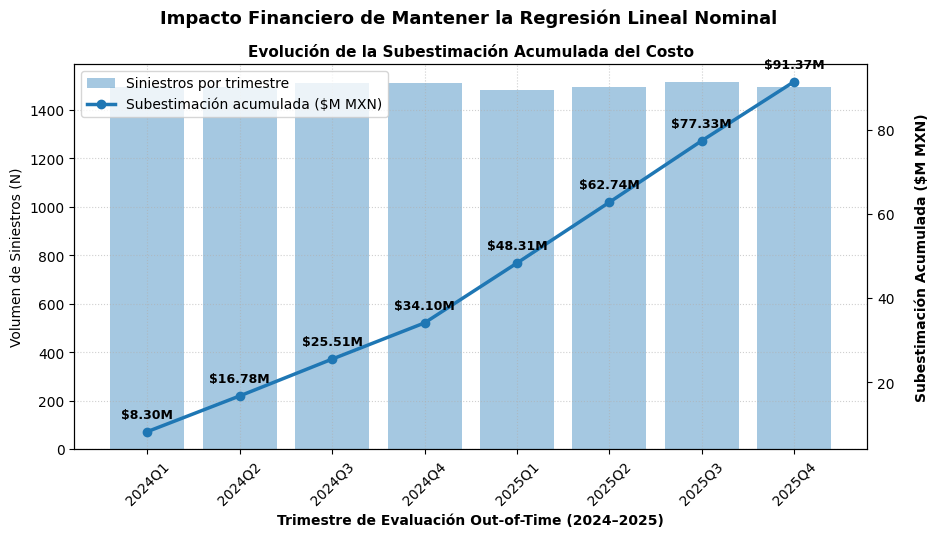

In [186]:

# IMPACTO FINANCIERO DE LA REGRESIÓN LINEAL NOMINAL


# El impacto se estima a partir del modelo de Regresión Lineal Nominal,
# utilizando el sesgo trimestral obtenido en el backtesting Out-of-Time.


# 1. Bias trimestral del modelo nominal


bias_nominal_lr = (
    bt_lr_inicial
    .set_index('Año - Trimestre')['Sesgo Promedio (Bias)']
    .to_dict()
)


# 2. Número de siniestros observados por trimestre


df_test['trimestre_str'] = df_test['trimestre'].astype(str)

volumen_siniestros = (
    df_test
    .groupby('trimestre_str')
    .size()
    .to_dict()
)


# 3. Estimación de la subestimación económica


impacto_data = []
subestimacion_acumulada = 0

for trim in sorted(bias_nominal_lr.keys()):

    n_siniestros = volumen_siniestros[trim]
    bias = bias_nominal_lr[trim]

    # El Bias se definió como:
    # Predicho - Real
    #
    # Por lo tanto, un Bias negativo representa subestimación.
    # Se toma únicamente la parte negativa del Bias para
    # dimensionar la subestimación económica.

    subestimacion_unitaria = max(0, -bias)

    subestimacion_trimestral = (
        subestimacion_unitaria * n_siniestros
    )

    subestimacion_acumulada += subestimacion_trimestral

    impacto_data.append({
        'Año - Trimestre': trim,
        'Siniestros (N)': n_siniestros,
        'Sesgo Promedio (Bias)': bias,
        'Subestimación Unitaria': subestimacion_unitaria,
        'Subestimación del Periodo': subestimacion_trimestral,
        'Subestimación Acumulada': subestimacion_acumulada
    })

df_impacto = pd.DataFrame(impacto_data)


# 4. Tabla de impacto financiero


print(
    "TABLA DE IMPACTO FINANCIERO OPERATIVO - "
    "REGRESIÓN LINEAL NOMINAL"
)

display(
    df_impacto.style.format({
        'Siniestros (N)': '{:,}',
        'Sesgo Promedio (Bias)': '${:,.2f} MXN',
        'Subestimación Unitaria': '${:,.2f} MXN',
        'Subestimación del Periodo': '${:,.2f} MXN',
        'Subestimación Acumulada': '${:,.2f} MXN'
    }).hide(axis='index')
)


# 5. Gráfica del impacto financiero


fig, ax1 = plt.subplots(figsize=(10.5, 5.5))

fig.suptitle(
    'Impacto Financiero de Mantener la Regresión Lineal Nominal',
    fontsize=13,
    fontweight='bold'
)


# Eje izquierdo: volumen de siniestros


ax1.set_xlabel(
    'Trimestre de Evaluación Out-of-Time (2024–2025)',
    fontweight='bold'
)

ax1.set_ylabel(
    'Volumen de Siniestros (N)'
)

ax1.bar(
    df_impacto['Año - Trimestre'],
    df_impacto['Siniestros (N)'],
    alpha=0.4,
    label='Siniestros por trimestre'
)

ax1.tick_params(
    axis='x',
    rotation=45
)

ax1.grid(
    True,
    linestyle=':',
    alpha=0.6
)


# Eje derecho: subestimación acumulada


ax2 = ax1.twinx()

ax2.plot(
    df_impacto['Año - Trimestre'],
    df_impacto['Subestimación Acumulada'] / 1e6,
    marker='o',
    linewidth=2.5,
    label='Subestimación acumulada ($M MXN)'
)

ax2.set_ylabel(
    'Subestimación Acumulada ($M MXN)',
    fontweight='bold',
    labelpad=15
)





for i, valor_m in enumerate(
    df_impacto['Subestimación Acumulada'] / 1e6
):

    ax2.annotate(
        f'${valor_m:.2f}M',
        (
            df_impacto['Año - Trimestre'].iloc[i],
            valor_m
        ),
        textcoords='offset points',
        xytext=(0, 10),
        fontsize=9,
        fontweight='bold',
        ha='center'
    )





ax1.set_title(
    'Evolución de la Subestimación Acumulada del Costo',
    fontsize=11,
    fontweight='bold'
)





lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left'
)


plt.subplots_adjust(
    right=0.88,
    bottom=0.18
)

plt.show()

### Interpretación del impacto

La gráfica muestra una tendencia creciente de la **subestimación acumulada** durante todo el periodo Out-of-Time. Durante 2024, la subestimación estimada por trimestre se mantiene alrededor de **$8.3 a $8.7 millones de pesos**; sin embargo, durante 2025 se observa un incremento, alcanzando aproximadamente entre **$14.0 y $14.6 millones por trimestre**.

Al finalizar 2025, la subestimación acumulada estimada alcanza aproximadamente **$91.37 millones de pesos**. Este resultado permite dimensionar el efecto económico de mantener un modelo que no se adapta al incremento observado en los costos de reparación.

Desde una perspectiva aseguradora, esta subestimación representa un riesgo para la toma de decisiones basada en las estimaciones del modelo, particularmente cuando estas se utilizan como referencia para la **proyección de costos, tarificación o evaluación de la suficiencia de recursos destinados a la atención de siniestros**.

La cifra obtenida debe interpretarse como una **aproximación de la subestimación acumulada del costo de reparación**, y no como una pérdida contable o un déficit formal de reservas, ya que el conjunto de datos disponible no contiene los elementos necesarios para realizar dicho cálculo.

En contraste, la aplicación de la **Estrategia A** reduce el Bias de la Regresión Lineal hasta **-$47.57 MXN**, frente a **-$7,614.47 MXN** del modelo nominal. Esto representa una reducción aproximada del **99.4% en la magnitud del sesgo**, evidenciando que la incorporación del índice de costos permite mitigar de manera efectiva el efecto del cambio en el nivel de precios de las refacciones.


# 6. Conclusiones

El análisis realizado permitió identificar un deterioro importante en el desempeño de los modelos al pasar del periodo de entrenamiento 2021–2023 al periodo Out-of-Time 2024–2025. El diagnóstico mostró evidencia de dos cambios relevantes en la cartera: una modificación en su composición, reflejada en la reducción de la edad media de los conductores de **43.6 a 26.0 años**, y un incremento en el costo promedio de reparación, que pasó de **$23,635.64 a $36,903.25 MXN**, equivalente a un aumento de **56.1%**.

El modelo nominal presentó una subestimación sistemática durante el periodo de prueba, con un Bias global cercano a **-$7,600 MXN** tanto para Gradient Boosting como para Regresión Lineal. Esto evidencia que mantener un modelo entrenado con información histórica sin considerar los cambios observados en la composición de la cartera y en el nivel de costos puede generar estimaciones insuficientes del costo esperado de reparación.

El impacto económico estimado también muestra la relevancia del problema. Utilizando la Regresión Lineal Nominal como referencia, la subestimación acumulada durante el periodo Out-of-Time alcanzó aproximadamente **$91.37 millones de pesos**. Esta cifra debe interpretarse como una aproximación de la subestimación acumulada del costo de reparación y no como una pérdida contable o un déficit formal de reservas, ya que los datos disponibles no permiten realizar dicha estimación financiera de manera directa.

Las dos estrategias implementadas permitieron mitigar el efecto del drift, aunque con diferente efectividad. La **Estrategia A, basada en la deflactación del costo de reparación mediante el índice de refacciones, obtuvo el mejor desempeño para ambos modelos en términos de MAE**, reduciéndolo aproximadamente **72%** respecto al modelo nominal y llevando el Bias a valores cercanos a cero. La Estrategia B, basada en una **Rolling Window de 24 meses**, también produjo una mejora respecto al modelo nominal, pero mantuvo una subestimación relevante.

Finalmente, las conclusiones fueron consistentes entre Gradient Boosting y Regresión Lineal. La similitud de sus resultados nominales y de la mejora obtenida mediante la deflactación sugiere que el deterioro observado está asociado principalmente al **cambio en la composición de la cartera y al incremento del nivel de costos de reparación**, más que a la elección del algoritmo. Debido a que la **Regresión Lineal con Deflactación** obtuvo el menor MAE y ofrece una mayor simplicidad e interpretabilidad, se selecciona como la alternativa preferida para este ejercicio.

En términos actuariales, el análisis muestra la importancia de **monitorear continuamente la evolución de la cartera y del nivel de costos**, así como de incorporar mecanismos de actualización que permitan mantener la estabilidad de las estimaciones ante cambios en las condiciones observadas. Para este conjunto de datos, la **deflactación mediante un índice de costos constituye una alternativa efectiva para reducir la subestimación y mitigar el deterioro del modelo ante la evolución de la cartera**, destacando la importancia de incorporar mecanismos de adaptación en modelos actuariales utilizados en entornos sujetos a cambios estructurales.

